In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("cafe_sales.csv")

# Preview data
df.head()

In [2]:
# Remove DK/NS from Items
df1 = df[df["Item"] != "DK/NS"].copy()
diff1_sample=(len(df)-len(df1))/len(df)*100
diff1_price=df["Price Per Unit"].mean() - df1["Price Per Unit"].mean()
diff1_total=df["Total Spent"].mean() - df1["Total Spent"].mean()

print(f"Records removed: {len(df)-len(df1)} in those:")
print(f"\t Price Per Unit = 3 either Cake or Juice")
print(f"\t Price Per Unit = 4 either Smoothie or Sandwich")
print(f"Statistically, this is {diff1_sample:.2f}% of the dataset")
print(f"- reducing the overall mean price per unit by £{diff1_price:.2f}")
print(f"- reducing the overall mean total spent by £{diff1_total:.2f}")

#print("\n")
#print (df[["Quantity", "Price Per Unit", "Total Spent"]].describe())
#print (df1[["Quantity", "Price Per Unit", "Total Spent"]].describe())

print("\n** For this section, I will proceed with the removal of DK from Items **")
df=df1.copy()

Records removed: 474 in those:
	 Price Per Unit = 3 either Cake or Juice
	 Price Per Unit = 4 either Smoothie or Sandwich
Statistically, this is 4.76% of the dataset
- reducing the overall mean price per unit by £0.03
- reducing the overall mean total spent by £0.09

** For this section, I will proceed with the removal of DK from Items **


In [3]:
# top items by quantity
def top_items_by_count(df, item_col="Item", qty_col="Quantity", n=10):
    grouped = (
        df.groupby(item_col, dropna=False)[qty_col]
          .sum()
          .sort_values(ascending=False)
          .reset_index(name="Total Quantity Sold")
    )
    total_qty = grouped["Total Quantity Sold"].sum()
    grouped["Percent"] = (grouped["Total Quantity Sold"] / total_qty * 100).round(2)
    return grouped.head(n)

# top items by revenue
def top_items_by_revenue(df, item_col="Item", revenue_col="Total Spent", n=10):
    grouped = (
        df.groupby(item_col, dropna=False)[revenue_col]
          .sum()
          .sort_values(ascending=False)
          .reset_index(name="Total Revenue")
    )
    total_rev = grouped["Total Revenue"].sum()
    grouped["Percent"] = (grouped["Total Revenue"] / total_rev * 100).round(2)
    return grouped.head(n)

# tables
print(f"Total Sample:{len(df)}")
top_count = top_items_by_count(df)
top_revenue = top_items_by_revenue(df)

print("\nTop Items by Quantity Sold (DK/NS Removed)")
print(top_count.to_string(index=False))

print("\nTop Items by Revenue (DK/NS Removed)")
print(top_revenue.to_string(index=False))

Total Sample:9491

Top Items by Quantity Sold (DK/NS Removed)
    Item  Total Quantity Sold  Percent
  Coffee                 3904    13.61
   Salad                 3819    13.31
     Tea                 3650    12.73
  Cookie                 3598    12.54
   Juice                 3505    12.22
    Cake                 3459    12.06
Sandwich                 3411    11.89
Smoothie                 3336    11.63

Top Items by Revenue (DK/NS Removed)
    Item  Total Revenue  Percent
   Salad        19095.0    22.77
Sandwich        13644.0    16.27
Smoothie        13344.0    15.91
   Juice        10515.0    12.54
    Cake        10377.0    12.37
  Coffee         7808.0     9.31
     Tea         5475.0     6.53
  Cookie         3598.0     4.29


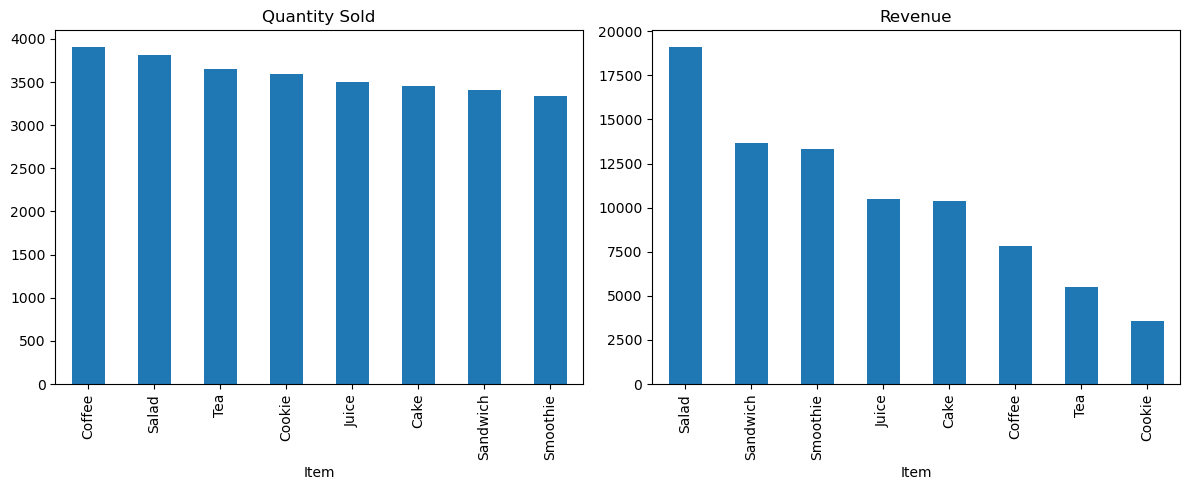

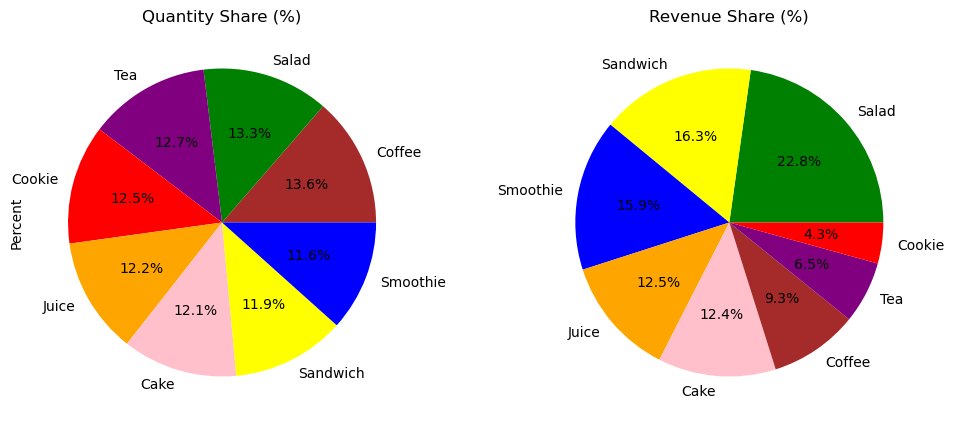

In [4]:
# Bar - figures
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

top_count.plot(
    kind="bar",
    x="Item",
    y="Total Quantity Sold",
    ax=axes[0],
    title="Quantity Sold",
    legend=False
)
top_revenue.plot(
    kind="bar",
    x="Item",
    y="Total Revenue",
    ax=axes[1],
    title="Revenue",
    legend=False
)
plt.tight_layout()
plt.show()

item_colors = {
    "Salad": "green",
    "Sandwich": "yellow",
    "Smoothie": "blue",
    "Juice": "orange",
    "Cake": "pink",
    "Coffee": "brown",
    "Tea": "purple",
    "Cookie": "red"
}

# Pie - percentages
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

top_count.set_index("Item")["Percent"].plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=axes[0],
    title="Quantity Share (%)",
    colors=[item_colors.get(item, "grey") for item in top_count["Item"]],
)
top_revenue.set_index("Item")["Percent"].plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=axes[1],
    title="Revenue Share (%)",
    colors=[item_colors.get(item, "grey") for item in top_revenue["Item"]],
)
plt.ylabel("")
plt.show()